# Traditional ML Experiments - Experiment 2: Time Features

**Phase 2:** Traditional Machine Learning Models

## Experiment 2: Time Features

This notebook evaluates the impact of **temporal features** on energy consumption prediction.

**Data:** `netop_ml_time.csv` (22 columns)
- **Raw features (13):** load, ESMode1-6, RUType, Mode, Frequency, Bandwidth, Antennas, TXpower
- **Time features (5):** hour_of_day, day_of_week, is_weekend, is_peak_hour, is_night_time

**Goal:** Measure the value of time-based patterns in energy prediction

## Models Evaluated
- Linear Regression (sanity check)
- Random Forest
- XGBoost
- LightGBM

## Expected Outcome
**10-25% improvement in MAE** over Baseline (Experiment 1)

Time features should capture daily/weekly patterns in network usage and energy consumption.

---
## 1. Imports and Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ Libraries imported successfully
Pandas version: 1.1.5
NumPy version: 1.19.5


---
## 2. Helper Functions

In [11]:
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(y_true, y_pred, dataset_name=""):
    """Calculate all evaluation metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = calculate_mape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    results = {
        'Dataset': dataset_name,
        'MAE (W)': mae,
        'RMSE (W)': rmse,
        'MAPE (%)': mape,
        'R²': r2
    }
    
    return results

def plot_predictions(y_true, y_pred, title="Actual vs Predicted", sample_size=1000):
    """Plot actual vs predicted values"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot (sample for visibility)
    idx = np.random.choice(len(y_true), min(sample_size, len(y_true)), replace=False)
    axes[0].scatter(y_true[idx], y_pred[idx], alpha=0.3, s=10)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
                 'r--', linewidth=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Energy (W)')
    axes[0].set_ylabel('Predicted Energy (W)')
    axes[0].set_title(f'{title}\nScatter Plot')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Residual plot
    residuals = y_true - y_pred
    axes[1].scatter(y_pred[idx], residuals[idx], alpha=0.3, s=10)
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted Energy (W)')
    axes[1].set_ylabel('Residuals (W)')
    axes[1].set_title(f'{title}\nResidual Plot')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✓ Helper functions defined")

✓ Helper functions defined


---
## 3. Load Data

In [12]:
print("="*80)
print("LOADING TIME FEATURES DATA")
print("="*80)

# Load time features dataset
df_time = pd.read_csv('../processed_data/netop_ml_time.csv')

print(f"\n✓ Time Features: {df_time.shape[0]:,} rows × {df_time.shape[1]} columns")

# Verify no missing values
print(f"\n🔍 Data Quality Check:")
print(f"  Missing values: {df_time.isnull().sum().sum()}")

# Show column names
print(f"\n📋 Columns ({len(df_time.columns)}):")
print(f"  {df_time.columns.tolist()}")

# Show energy statistics
print(f"\n📊 Target Variable (Energy) Statistics:")
print(f"  Mean:   {df_time['Energy'].mean():.2f} W")
print(f"  Std:    {df_time['Energy'].std():.2f} W")
print(f"  Min:    {df_time['Energy'].min():.2f} W")
print(f"  Max:    {df_time['Energy'].max():.2f} W")
print(f"  Median: {df_time['Energy'].median():.2f} W")

# Show sample
print(f"\n📄 Sample Data (first 3 rows):")
print(df_time.head(3))

LOADING TIME FEATURES DATA

✓ Time Features: 72,569 rows × 22 columns

🔍 Data Quality Check:
  Missing values: 0

📋 Columns (22):
  ['Time', 'BS', 'CellName', 'load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'Energy', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_night_time']

📊 Target Variable (Energy) Statistics:
  Mean:   28.64 W
  Std:    13.93 W
  Min:    3.59 W
  Max:    100.00 W
  Median: 24.66 W

📄 Sample Data (first 3 rows):
                  Time   BS CellName      load  ESMode1  ESMode2  ESMode3  \
0  2023-01-02 06:00:00  B_0    Cell0  0.197032      0.0      0.0      0.0   
1  2023-01-02 08:00:00  B_0    Cell0  0.781287      0.0      0.0      0.0   
2  2023-01-02 09:00:00  B_0    Cell0  0.863319      0.0      0.0      0.0   

   ESMode4  ESMode5  ESMode6 RUType   Mode  Frequency  Bandwidth  Antennas  \
0        0      0.0      0.0  Type1  Mode2      365.0         20 

---
## 4. Experiment 2: Time Features

**Data:** `netop_ml_time.csv` (22 columns)

**Features:** Raw (13) + Time (5) = 18 features
- Raw: load, ESMode1-6, RUType, Mode, Frequency, Bandwidth, Antennas, TXpower
- Time: hour_of_day, day_of_week, is_weekend, is_peak_hour, is_night_time

**Goal:** Measure improvement from temporal patterns

In [13]:
print("="*80)
print("EXPERIMENT 2: TIME FEATURES")
print("="*80)

# Separate features and target
exclude_cols = ['Time', 'BS', 'CellName', 'Energy']
feature_cols_time = [col for col in df_time.columns if col not in exclude_cols]

print(f"\n📋 Features ({len(feature_cols_time)}):")
print(f"  {feature_cols_time}")

X_time = df_time[feature_cols_time]
y_time = df_time['Energy']

print(f"\n✓ X shape: {X_time.shape}")
print(f"✓ y shape: {y_time.shape}")

EXPERIMENT 2: TIME FEATURES

📋 Features (18):
  ['load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_night_time']

✓ X shape: (72569, 18)
✓ y shape: (72569,)


### 4.1 Temporal Train-Test Split

**Important:** We use temporal split (not random) to respect time series nature:
- **Training set (80%):** First 80% of data for cross-validation and model training
- **Test set (20%):** Last 20% of data held out for final evaluation

This prevents data leakage and ensures proper generalization testing.

In [14]:
print("\n" + "="*80)
print("TEMPORAL TRAIN-TEST SPLIT")
print("="*80)

# Calculate split point (80/20 temporal split)
split_idx = int(len(X_time) * 0.8)

# Split features and target
X_train_full = X_time.iloc[:split_idx]
y_train_full = y_time.iloc[:split_idx]
X_test = X_time.iloc[split_idx:]
y_test = y_time.iloc[split_idx:]

print(f"\nTotal samples: {len(X_time):,}")
print(f"Training set: {len(X_train_full):,} samples (80%)")
print(f"Test set: {len(X_test):,} samples (20%)")

# Show temporal boundaries
print(f"\n📅 Temporal boundaries:")
print(f"  Training: {df_time['Time'].iloc[0]} to {df_time['Time'].iloc[split_idx-1]}")
print(f"  Test:     {df_time['Time'].iloc[split_idx]} to {df_time['Time'].iloc[-1]}")

print(f"\n✓ Temporal split complete")


TEMPORAL TRAIN-TEST SPLIT

Total samples: 72,569
Training set: 58,055 samples (80%)
Test set: 14,514 samples (20%)

📅 Temporal boundaries:
  Training: 2023-01-02 06:00:00 to 2023-01-02 23:00:00
  Test:     2023-01-03 00:00:00 to 2023-01-07 13:00:00

✓ Temporal split complete


### 4.2 Preprocessing Pipeline Setup

In [15]:
# Identify numerical and categorical features
categorical_features = ['RUType', 'Mode']
numerical_features = [col for col in feature_cols_time if col not in categorical_features]

print(f"\n🔢 Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"🏷️  Categorical features ({len(categorical_features)}): {categorical_features}")

# Create preprocessing pipeline
preprocessor_time = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse=False), categorical_features)
    ])

print("\n✓ Preprocessing pipeline created")


🔢 Numerical features (16): ['load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_night_time']
🏷️  Categorical features (2): ['RUType', 'Mode']

✓ Preprocessing pipeline created


### 4.3 Time Series Cross-Validation Setup

In [16]:
# TimeSeriesSplit with 5 folds
tscv = TimeSeriesSplit(n_splits=5)

print("\n📅 Time Series Cross-Validation Setup:")
print(f"  Number of splits: 5")
print(f"  Total samples: {len(X_time):,}")
print(f"\n  Fold sizes:")

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_time), 1):
    print(f"    Fold {fold_idx}: Train={len(train_idx):>6,} | Val={len(val_idx):>6,}")


📅 Time Series Cross-Validation Setup:
  Number of splits: 5
  Total samples: 72,569

  Fold sizes:
    Fold 1: Train=12,099 | Val=12,094
    Fold 2: Train=24,193 | Val=12,094
    Fold 3: Train=36,287 | Val=12,094
    Fold 4: Train=48,381 | Val=12,094
    Fold 5: Train=60,475 | Val=12,094


### 4.4 Model 1: Linear Regression

In [17]:
print("\n" + "="*60)
print("Model: Linear Regression (Time Features)")
print("="*60)

# Create pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_time),
    ('regressor', LinearRegression())
])

# Cross-validation on TRAINING SET ONLY
lr_results = []
for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_full), 1):
    print(f"  Training Fold {fold_idx}...", end=" ")
    
    # Split data
    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    
    # Train
    lr_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = lr_pipeline.predict(X_val)
    
    # Evaluate
    results = evaluate_model(y_val.values, y_pred, f"Fold {fold_idx}")
    lr_results.append(results)
    
    print(f"MAE={results['MAE (W)']:>6.2f} W | RMSE={results['RMSE (W)']:>6.2f} W | R²={results['R²']:>6.4f}")

# Average results
lr_avg = pd.DataFrame(lr_results).mean()
print(f"\n  {'='*58}")
print(f"  CV Avg: MAE={lr_avg['MAE (W)']:>6.2f} W | RMSE={lr_avg['RMSE (W)']:>6.2f} W | R²={lr_avg['R²']:>6.4f}")
print(f"  {'='*58}")

# Train on FULL TRAINING SET
print("\n  Training on full training set...")
lr_pipeline.fit(X_train_full, y_train_full)

# Evaluate on TEST SET
y_pred_test_lr = lr_pipeline.predict(X_test)
lr_test_results = evaluate_model(y_test.values, y_pred_test_lr, "Test Set")

print(f"\n  {'='*58}")
print(f"  Test:   MAE={lr_test_results['MAE (W)']:>6.2f} W | RMSE={lr_test_results['RMSE (W)']:>6.2f} W | R²={lr_test_results['R²']:>6.4f}")
print(f"  {'='*58}")

print("\n✓ Linear Regression training complete")


Model: Linear Regression (Time Features)
  Training Fold 1... MAE=1118055538405.24 W | RMSE=8861879103693.87 W | R²=-516776924650867362103296.0000
  Training Fold 2... MAE=  3.95 W | RMSE=  5.33 W | R²=0.8674
  Training Fold 3... MAE=  4.30 W | RMSE=  5.85 W | R²=0.8186
  Training Fold 4... MAE=  4.27 W | RMSE=  5.78 W | R²=0.8138
  Training Fold 5... MAE=  3.33 W | RMSE=  4.42 W | R²=0.8838

  CV Avg: MAE=223611107684.22 W | RMSE=1772375820743.05 W | R²=-103355384930173469065216.0000

  Training on full training set...

  Test:   MAE=  3.49 W | RMSE=  4.86 W | R²=0.8803

✓ Linear Regression training complete


### 4.5 Model 2: Random Forest

In [18]:
print("\n" + "="*60)
print("Model: Random Forest (Time Features)")
print("="*60)

# Create pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_time),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    ))
])

# Cross-validation on TRAINING SET ONLY
rf_results = []
for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_full), 1):
    print(f"  Training Fold {fold_idx}...", end=" ")
    
    # Split data
    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    
    # Train
    rf_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = rf_pipeline.predict(X_val)
    
    # Evaluate
    results = evaluate_model(y_val.values, y_pred, f"Fold {fold_idx}")
    rf_results.append(results)
    
    print(f"MAE={results['MAE (W)']:>6.2f} W | RMSE={results['RMSE (W)']:>6.2f} W | R²={results['R²']:>6.4f}")

# Average results
rf_avg = pd.DataFrame(rf_results).mean()
print(f"\n  {'='*58}")
print(f"  CV Avg: MAE={rf_avg['MAE (W)']:>6.2f} W | RMSE={rf_avg['RMSE (W)']:>6.2f} W | R²={rf_avg['R²']:>6.4f}")
print(f"  {'='*58}")

# Train on FULL TRAINING SET
print("\n  Training on full training set...")
rf_pipeline.fit(X_train_full, y_train_full)

# Evaluate on TEST SET
y_pred_test_rf = rf_pipeline.predict(X_test)
rf_test_results = evaluate_model(y_test.values, y_pred_test_rf, "Test Set")

print(f"\n  {'='*58}")
print(f"  Test:   MAE={rf_test_results['MAE (W)']:>6.2f} W | RMSE={rf_test_results['RMSE (W)']:>6.2f} W | R²={rf_test_results['R²']:>6.4f}")
print(f"  {'='*58}")

print("\n✓ Random Forest training complete")


Model: Random Forest (Time Features)
  Training Fold 1... MAE=  3.46 W | RMSE=  4.93 W | R²=0.8403
  Training Fold 2... MAE=  3.44 W | RMSE=  4.94 W | R²=0.8860
  Training Fold 3... MAE=  3.73 W | RMSE=  5.47 W | R²=0.8417
  Training Fold 4... MAE=  4.04 W | RMSE=  6.09 W | R²=0.7933
  Training Fold 5... MAE=  2.89 W | RMSE=  4.09 W | R²=0.9008

  CV Avg: MAE=  3.51 W | RMSE=  5.10 W | R²=0.8524

  Training on full training set...

  Test:   MAE=  3.25 W | RMSE=  4.89 W | R²=0.8787

✓ Random Forest training complete


### 4.6 Model 3: XGBoost

In [19]:
print("\n" + "="*60)
print("Model: XGBoost (Time Features)")
print("="*60)

# Create pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_time),
    ('regressor', XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ))
])

# Cross-validation on TRAINING SET ONLY
xgb_results = []
for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_full), 1):
    print(f"  Training Fold {fold_idx}...", end=" ")
    
    # Split data
    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    
    # Train
    xgb_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = xgb_pipeline.predict(X_val)
    
    # Evaluate
    results = evaluate_model(y_val.values, y_pred, f"Fold {fold_idx}")
    xgb_results.append(results)
    
    print(f"MAE={results['MAE (W)']:>6.2f} W | RMSE={results['RMSE (W)']:>6.2f} W | R²={results['R²']:>6.4f}")

# Average results
xgb_avg = pd.DataFrame(xgb_results).mean()
print(f"\n  {'='*58}")
print(f"  CV Avg: MAE={xgb_avg['MAE (W)']:>6.2f} W | RMSE={xgb_avg['RMSE (W)']:>6.2f} W | R²={xgb_avg['R²']:>6.4f}")
print(f"  {'='*58}")

# Train on FULL TRAINING SET
print("\n  Training on full training set...")
xgb_pipeline.fit(X_train_full, y_train_full)

# Evaluate on TEST SET
y_pred_test_xgb = xgb_pipeline.predict(X_test)
xgb_test_results = evaluate_model(y_test.values, y_pred_test_xgb, "Test Set")

print(f"\n  {'='*58}")
print(f"  Test:   MAE={xgb_test_results['MAE (W)']:>6.2f} W | RMSE={xgb_test_results['RMSE (W)']:>6.2f} W | R²={xgb_test_results['R²']:>6.4f}")
print(f"  {'='*58}")

print("\n✓ XGBoost training complete")


Model: XGBoost (Time Features)
  Training Fold 1... MAE=  3.08 W | RMSE=  4.30 W | R²=0.8786
  Training Fold 2... MAE=  3.30 W | RMSE=  4.72 W | R²=0.8959
  Training Fold 3... MAE=  3.62 W | RMSE=  5.22 W | R²=0.8557
  Training Fold 4... MAE=  4.03 W | RMSE=  5.87 W | R²=0.8080
  Training Fold 5... MAE=  2.73 W | RMSE=  3.76 W | R²=0.9158

  CV Avg: MAE=  3.35 W | RMSE=  4.77 W | R²=0.8708

  Training on full training set...

  Test:   MAE=  3.15 W | RMSE=  4.63 W | R²=0.8916

✓ XGBoost training complete


### 4.7 Model 4: LightGBM

In [20]:
print("\n" + "="*60)
print("Model: LightGBM (Time Features)")
print("="*60)

# Create pipeline
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor_time),
    ('regressor', LGBMRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ))
])

# Cross-validation on TRAINING SET ONLY
lgbm_results = []
for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_full), 1):
    print(f"  Training Fold {fold_idx}...", end=" ")
    
    # Split data
    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    
    # Train
    lgbm_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = lgbm_pipeline.predict(X_val)
    
    # Evaluate
    results = evaluate_model(y_val.values, y_pred, f"Fold {fold_idx}")
    lgbm_results.append(results)
    
    print(f"MAE={results['MAE (W)']:>6.2f} W | RMSE={results['RMSE (W)']:>6.2f} W | R²={results['R²']:>6.4f}")

# Average results
lgbm_avg = pd.DataFrame(lgbm_results).mean()
print(f"\n  {'='*58}")
print(f"  CV Avg: MAE={lgbm_avg['MAE (W)']:>6.2f} W | RMSE={lgbm_avg['RMSE (W)']:>6.2f} W | R²={lgbm_avg['R²']:>6.4f}")
print(f"  {'='*58}")

# Train on FULL TRAINING SET
print("\n  Training on full training set...")
lgbm_pipeline.fit(X_train_full, y_train_full)

# Evaluate on TEST SET
y_pred_test_lgbm = lgbm_pipeline.predict(X_test)
lgbm_test_results = evaluate_model(y_test.values, y_pred_test_lgbm, "Test Set")

print(f"\n  {'='*58}")
print(f"  Test:   MAE={lgbm_test_results['MAE (W)']:>6.2f} W | RMSE={lgbm_test_results['RMSE (W)']:>6.2f} W | R²={lgbm_test_results['R²']:>6.4f}")
print(f"  {'='*58}")

print("\n✓ LightGBM training complete")


Model: LightGBM (Time Features)
  Training Fold 1... MAE=  3.33 W | RMSE=  5.27 W | R²=0.8175
  Training Fold 2... MAE=  3.22 W | RMSE=  4.54 W | R²=0.9035
  Training Fold 3... MAE=  3.63 W | RMSE=  5.26 W | R²=0.8536
  Training Fold 4... MAE=  4.01 W | RMSE=  5.79 W | R²=0.8135
  Training Fold 5... MAE=  2.82 W | RMSE=  3.89 W | R²=0.9099

  CV Avg: MAE=  3.40 W | RMSE=  4.95 W | R²=0.8596

  Training on full training set...

  Test:   MAE=  3.14 W | RMSE=  4.57 W | R²=0.8942

✓ LightGBM training complete


### 4.8 Experiment 2 Summary

In [21]:
print("\n" + "="*80)
print("EXPERIMENT 2: TIME FEATURES - SUMMARY")
print("="*80)

# Compile CV results
exp2_cv_summary = pd.DataFrame([
    {'Model': 'Linear Regression', **{k: v for k, v in lr_avg.items() if k != 'Dataset'}},
    {'Model': 'Random Forest', **{k: v for k, v in rf_avg.items() if k != 'Dataset'}},
    {'Model': 'XGBoost', **{k: v for k, v in xgb_avg.items() if k != 'Dataset'}},
    {'Model': 'LightGBM', **{k: v for k, v in lgbm_avg.items() if k != 'Dataset'}}
])

# Compile test results
exp2_test_summary = pd.DataFrame([
    {'Model': 'Linear Regression', **{k: v for k, v in lr_test_results.items() if k != 'Dataset'}},
    {'Model': 'Random Forest', **{k: v for k, v in rf_test_results.items() if k != 'Dataset'}},
    {'Model': 'XGBoost', **{k: v for k, v in xgb_test_results.items() if k != 'Dataset'}},
    {'Model': 'LightGBM', **{k: v for k, v in lgbm_test_results.items() if k != 'Dataset'}}
])

# Sort by R² descending
exp2_cv_summary = exp2_cv_summary.sort_values('R²', ascending=False)
exp2_test_summary = exp2_test_summary.sort_values('R²', ascending=False)

print("\n📊 Cross-Validation Results (5-fold average on training set):")
print(exp2_cv_summary.to_string(index=False))

print("\n📊 Test Set Results (held-out 20%):")
print(exp2_test_summary.to_string(index=False))

# Find best model (by test R²)
best_model_exp2 = exp2_test_summary.iloc[0]['Model']
best_r2_exp2 = exp2_test_summary.iloc[0]['R²']
best_mae_exp2 = exp2_test_summary.iloc[0]['MAE (W)']

print(f"\n🏆 Best Model (Test Set): {best_model_exp2}")
print(f"   Test R² = {best_r2_exp2:.4f} | Test MAE = {best_mae_exp2:.2f} W")

# Check success criteria (on test set)
mean_energy = y_test.mean()
mae_threshold = 0.20 * mean_energy  # 20% of mean

print(f"\n✅ Success Criteria Check (Test Set):")
print(f"   R² > 0.7:          {'✓ PASS' if best_r2_exp2 > 0.7 else '✗ FAIL'} ({best_r2_exp2:.4f})")
print(f"   MAE < 20% of mean: {'✓ PASS' if best_mae_exp2 < mae_threshold else '✗ FAIL'} ({best_mae_exp2:.2f} W < {mae_threshold:.2f} W)")

# Store for saving and comparison
exp2_summary = exp2_test_summary


EXPERIMENT 2: TIME FEATURES - SUMMARY

📊 Cross-Validation Results (5-fold average on training set):
             Model       MAE (W)      RMSE (W)      MAPE (%)            R²
           XGBoost  3.351802e+00  4.774327e+00  1.273987e+01  8.707697e-01
          LightGBM  3.401290e+00  4.949557e+00  1.288574e+01  8.595918e-01
     Random Forest  3.513275e+00  5.102163e+00  1.332003e+01  8.523985e-01
 Linear Regression  2.236111e+11  1.772376e+12  5.472727e+11 -1.033554e+23

📊 Test Set Results (held-out 20%):
             Model   MAE (W)  RMSE (W)   MAPE (%)        R²
          LightGBM  3.140131  4.571353  11.056167  0.894157
           XGBoost  3.146096  4.625932  11.093775  0.891614
 Linear Regression  3.492590  4.862163  13.437387  0.880262
     Random Forest  3.254012  4.894526  11.566516  0.878662

🏆 Best Model (Test Set): LightGBM
   Test R² = 0.8942 | Test MAE = 3.14 W

✅ Success Criteria Check (Test Set):
   R² > 0.7:          ✓ PASS (0.8942)
   MAE < 20% of mean: ✓ PASS (3.14 W 

### 4.9 Comparison with Baseline

In [22]:
print("\n" + "="*80)
print("COMPARISON: BASELINE vs TIME FEATURES (TEST SET)")
print("="*80)

# Load baseline results
try:
    baseline_results = pd.read_csv('../results/traditional_ml_baseline_results.csv')
    
    print("\n📊 Performance Comparison (Best Models on Test Set):") 
    print("\nBaseline (Experiment 1):")
    print(baseline_results.sort_values('R²', ascending=False).head(1).to_string(index=False))
    
    print("\nTime Features (Experiment 2):")
    print(exp2_test_summary.head(1).to_string(index=False))
    
    # Calculate improvement
    baseline_best_mae = baseline_results.sort_values('R²', ascending=False).iloc[0]['MAE (W)']
    baseline_best_r2 = baseline_results.sort_values('R²', ascending=False).iloc[0]['R²']
    
    mae_improvement = ((baseline_best_mae - best_mae_exp2) / baseline_best_mae) * 100
    r2_improvement = ((best_r2_exp2 - baseline_best_r2) / baseline_best_r2) * 100
    
    print(f"\n📈 Improvement from Adding Time Features:")
    print(f"   MAE: {mae_improvement:>6.2f}% reduction ({baseline_best_mae:.2f} W → {best_mae_exp2:.2f} W)")
    print(f"   R²:  {r2_improvement:>6.2f}% increase ({baseline_best_r2:.4f} → {best_r2_exp2:.4f})")
    
    # Check if improvement meets expectation
    print(f"\n✅ Expected Improvement: 10-25% MAE reduction")
    if 10 <= mae_improvement <= 25:
        print(f"   ✓ WITHIN TARGET ({mae_improvement:.2f}%)")
    elif mae_improvement > 25:
        print(f"   ✓ EXCEEDS TARGET ({mae_improvement:.2f}%)")
    else:
        print(f"   ✗ BELOW TARGET ({mae_improvement:.2f}%)")
        
except FileNotFoundError:
    print("\n⚠️  Baseline results not found. Run traditional_ml_baseline.ipynb first.")


COMPARISON: BASELINE vs TIME FEATURES (TEST SET)

📊 Performance Comparison (Best Models on Test Set):

Baseline (Experiment 1):
    Model   MAE (W)  RMSE (W)  MAPE (%)       R²
 LightGBM  3.340572  4.791432  12.28608  0.88372

Time Features (Experiment 2):
    Model   MAE (W)  RMSE (W)   MAPE (%)        R²
 LightGBM  3.140131  4.571353  11.056167  0.894157

📈 Improvement from Adding Time Features:
   MAE:   6.00% reduction (3.34 W → 3.14 W)
   R²:    1.18% increase (0.8837 → 0.8942)

✅ Expected Improvement: 10-25% MAE reduction
   ✗ BELOW TARGET (6.00%)


### 4.10 Visualize Best Model

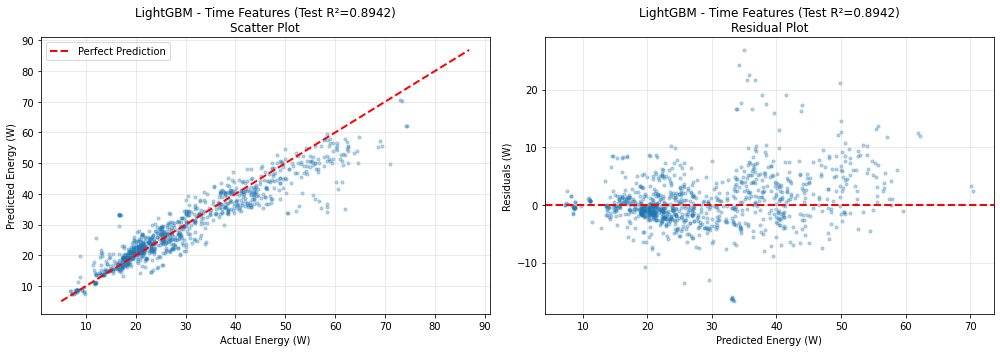

In [23]:
# Plot predictions for best model on TEST SET
if best_model_exp2 == 'XGBoost':
    plot_predictions(y_test.values, y_pred_test_xgb, f"XGBoost - Time Features (Test R²={best_r2_exp2:.4f})")
elif best_model_exp2 == 'LightGBM':
    plot_predictions(y_test.values, y_pred_test_lgbm, f"LightGBM - Time Features (Test R²={best_r2_exp2:.4f})")
elif best_model_exp2 == 'Random Forest':
    plot_predictions(y_test.values, y_pred_test_rf, f"Random Forest - Time Features (Test R²={best_r2_exp2:.4f})")
else:
    plot_predictions(y_test.values, y_pred_test_lr, f"Linear Regression - Time Features (Test R²={best_r2_exp2:.4f})")

### 4.11 Feature Importance Analysis

In [24]:
print("="*80)
print("FEATURE IMPORTANCE ANALYSIS - TIME FEATURES")
print("="*80)

print("\nNote: Feature importance extracted from models trained on full training set (80% of data)")

# Get feature names after preprocessing
# Models have already been fitted on training set during training

# Get numerical feature names (unchanged)
num_feature_names = numerical_features

# Get categorical feature names after one-hot encoding
cat_encoder = preprocessor_time.named_transformers_['cat']
cat_feature_names = []
for i, cat in enumerate(categorical_features):
    categories = cat_encoder.categories_[i][1:]  # Skip first category
    cat_feature_names.extend([f"{cat}_{cat_val}" for cat_val in categories])

# Combine all feature names
all_feature_names = num_feature_names + cat_feature_names

print(f"\n📋 Total features after preprocessing: {len(all_feature_names)}")
print(f"   Numerical: {len(num_feature_names)}")
print(f"   Categorical (one-hot): {len(cat_feature_names)}")

# Identify time features
time_feature_names = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_night_time']
print(f"\n⏰ Time features: {time_feature_names}")

# Extract feature importance from each model
print("\n" + "="*80)
print("Extracting Feature Importances...")
print("="*80)

# XGBoost
xgb_importance = xgb_pipeline.named_steps['regressor'].feature_importances_
xgb_fi_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False)

print("\n🥇 XGBoost - Top 10 Features:")
print(xgb_fi_df.head(10).to_string(index=False))

# LightGBM
lgbm_importance = lgbm_pipeline.named_steps['regressor'].feature_importances_
lgbm_fi_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': lgbm_importance
}).sort_values('Importance', ascending=False)

print("\n🥈 LightGBM - Top 10 Features:")
print(lgbm_fi_df.head(10).to_string(index=False))

# Random Forest
rf_importance = rf_pipeline.named_steps['regressor'].feature_importances_
rf_fi_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)

print("\n🥉 Random Forest - Top 10 Features:")
print(rf_fi_df.head(10).to_string(index=False))

# Highlight time features
print("\n" + "="*80)
print("TIME FEATURES RANKING")
print("="*80)

print("\n⏰ Time Features Importance (XGBoost):")
xgb_time_features = xgb_fi_df[xgb_fi_df['Feature'].isin(time_feature_names)]
print(xgb_time_features.to_string(index=False))

print("\n⏰ Time Features Importance (LightGBM):")
lgbm_time_features = lgbm_fi_df[lgbm_fi_df['Feature'].isin(time_feature_names)]
print(lgbm_time_features.to_string(index=False))

print("\n⏰ Time Features Importance (Random Forest):")
rf_time_features = rf_fi_df[rf_fi_df['Feature'].isin(time_feature_names)]
print(rf_time_features.to_string(index=False))

FEATURE IMPORTANCE ANALYSIS - TIME FEATURES

Note: Feature importance extracted from models trained on full training set (80% of data)

📋 Total features after preprocessing: 22
   Numerical: 16
   Categorical (one-hot): 6

⏰ Time features: ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_night_time']

Extracting Feature Importances...

🥇 XGBoost - Top 10 Features:
      Feature  Importance
 RUType_Type7    0.198816
     Antennas    0.190163
    Frequency    0.170026
    Bandwidth    0.092657
         load    0.081017
 RUType_Type4    0.055934
 RUType_Type2    0.036269
      ESMode1    0.032847
 RUType_Type6    0.032284
 RUType_Type5    0.028339

🥈 LightGBM - Top 10 Features:
      Feature  Importance
         load         649
  hour_of_day         587
      TXpower         351
    Frequency         326
     Antennas         241
 RUType_Type7         127
  day_of_week         126
 RUType_Type5          76
 RUType_Type2          74
      ESMode1          67

🥉 Random Fore

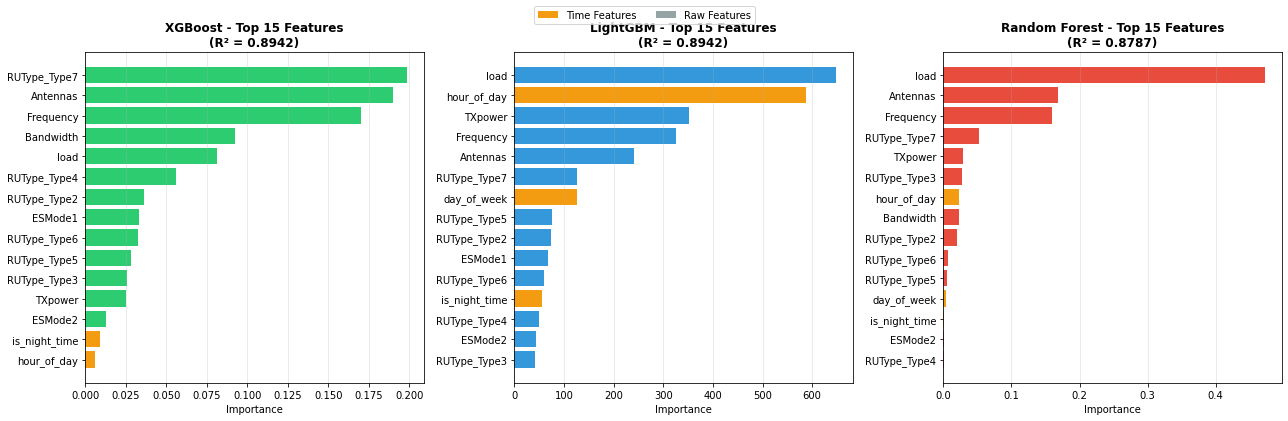


✓ Feature importance visualization complete


In [25]:
# Visualize feature importance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
top_n = 15
xgb_top = xgb_fi_df.head(top_n)
colors = ['#f39c12' if feat in time_feature_names else '#2ecc71' for feat in xgb_top['Feature']]
axes[0].barh(range(len(xgb_top)), xgb_top['Importance'], color=colors)
axes[0].set_yticks(range(len(xgb_top)))
axes[0].set_yticklabels(xgb_top['Feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title(f'XGBoost - Top {top_n} Features\n(R² = {best_r2_exp2:.4f})', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# LightGBM
lgbm_top = lgbm_fi_df.head(top_n)
colors = ['#f39c12' if feat in time_feature_names else '#3498db' for feat in lgbm_top['Feature']]
axes[1].barh(range(len(lgbm_top)), lgbm_top['Importance'], color=colors)
axes[1].set_yticks(range(len(lgbm_top)))
axes[1].set_yticklabels(lgbm_top['Feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance')
lgbm_r2 = exp2_summary[exp2_summary['Model'] == 'LightGBM']['R²'].values[0]
axes[1].set_title(f'LightGBM - Top {top_n} Features\n(R² = {lgbm_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Random Forest
rf_top = rf_fi_df.head(top_n)
colors = ['#f39c12' if feat in time_feature_names else '#e74c3c' for feat in rf_top['Feature']]
axes[2].barh(range(len(rf_top)), rf_top['Importance'], color=colors)
axes[2].set_yticks(range(len(rf_top)))
axes[2].set_yticklabels(rf_top['Feature'])
axes[2].invert_yaxis()
axes[2].set_xlabel('Importance')
rf_r2 = exp2_summary[exp2_summary['Model'] == 'Random Forest']['R²'].values[0]
axes[2].set_title(f'Random Forest - Top {top_n} Features\n(R² = {rf_r2:.4f})', fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#f39c12', label='Time Features'),
    Patch(facecolor='#95a5a6', label='Raw Features')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.98))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n✓ Feature importance visualization complete")


CONSENSUS FEATURE IMPORTANCE

📊 Top 15 Features by Average Importance:
       Feature   Average       Std   XGBoost  LightGBM  RandomForest
  RUType_Type7  0.802500  0.342080  0.407500  1.000000      1.000000
     Bandwidth  0.565308  0.264082  0.855192  0.502311      0.338422
          load  0.561697  0.341961  0.956477  0.371341      0.357275
  is_peak_hour  0.435831  0.490382  1.000000  0.195686      0.111807
  RUType_Type3  0.328100  0.499232  0.030861  0.904468      0.048971
 is_night_time  0.242448  0.260481  0.126058  0.540832      0.060455
       ESMode1  0.187120  0.241556  0.466045  0.047766      0.047550
   hour_of_day  0.120383  0.144252  0.281336  0.077042      0.002770
      Antennas  0.113047  0.069871  0.182426  0.114022      0.042694
       ESMode2  0.090322  0.082112  0.165213  0.103236      0.002518
   day_of_week  0.089872  0.070355  0.142541  0.117103      0.009972
    is_weekend  0.089531  0.074352  0.162381  0.092450      0.013762
       TXpower  0.084150  0.040

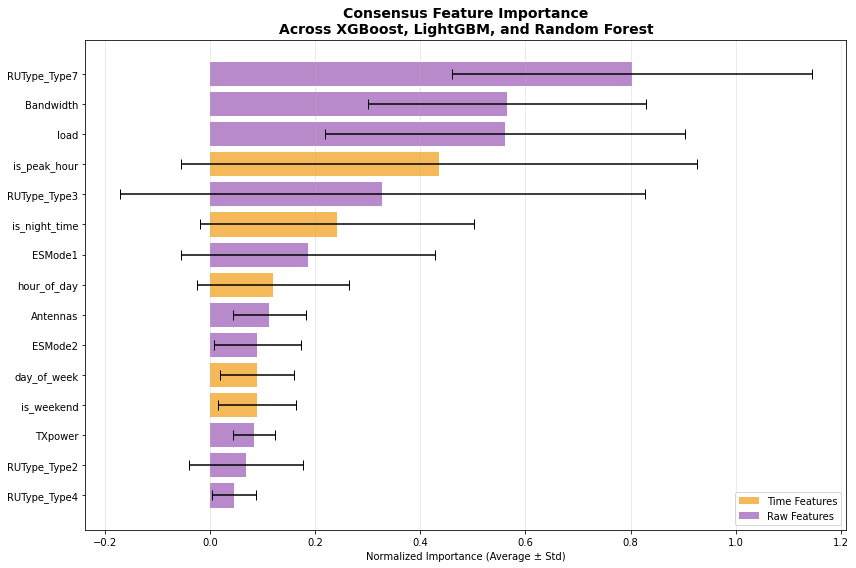


✓ Consensus analysis complete


In [26]:
# Consensus analysis
print("\n" + "="*80)
print("CONSENSUS FEATURE IMPORTANCE")
print("="*80)

# Normalize importances
xgb_fi_df['Importance_Norm'] = xgb_fi_df['Importance'] / xgb_fi_df['Importance'].max()
lgbm_fi_df['Importance_Norm'] = lgbm_fi_df['Importance'] / lgbm_fi_df['Importance'].max()
rf_fi_df['Importance_Norm'] = rf_fi_df['Importance'] / rf_fi_df['Importance'].max()

# Create consensus dataframe
consensus_df = pd.DataFrame({
    'Feature': all_feature_names,
    'XGBoost': xgb_fi_df.set_index('Feature')['Importance_Norm'],
    'LightGBM': lgbm_fi_df.set_index('Feature')['Importance_Norm'],
    'RandomForest': rf_fi_df.set_index('Feature')['Importance_Norm']
})

# Calculate average
consensus_df['Average'] = consensus_df[['XGBoost', 'LightGBM', 'RandomForest']].mean(axis=1)
consensus_df['Std'] = consensus_df[['XGBoost', 'LightGBM', 'RandomForest']].std(axis=1)
consensus_df = consensus_df.sort_values('Average', ascending=False)

print("\n📊 Top 15 Features by Average Importance:")
print(consensus_df[['Feature', 'Average', 'Std', 'XGBoost', 'LightGBM', 'RandomForest']].head(15).to_string(index=False))

# Visualize consensus
fig, ax = plt.subplots(figsize=(12, 8))
top_consensus = consensus_df.head(15)
x = range(len(top_consensus))
colors = ['#f39c12' if feat in time_feature_names else '#9b59b6' for feat in top_consensus['Feature']]

ax.barh(x, top_consensus['Average'], xerr=top_consensus['Std'], 
        color=colors, alpha=0.7, capsize=5)
ax.set_yticks(x)
ax.set_yticklabels(top_consensus['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Normalized Importance (Average ± Std)')
ax.set_title('Consensus Feature Importance\nAcross XGBoost, LightGBM, and Random Forest', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add legend
legend_elements = [
    Patch(facecolor='#f39c12', alpha=0.7, label='Time Features'),
    Patch(facecolor='#9b59b6', alpha=0.7, label='Raw Features')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print("\n✓ Consensus analysis complete")

---
## 5. Save Experiment 2 Results

In [27]:
# Save results to CSV
exp2_summary.to_csv('../results/traditional_ml_time_results.csv', index=False)
print("✓ Experiment 2 results saved to ../results/traditional_ml_time_results.csv")

# Save best model
import joblib
if best_model_exp2 == 'XGBoost':
    joblib.dump(xgb_pipeline, '../models/xgboost_time.pkl')
    print("✓ Best model (XGBoost) saved to ../models/xgboost_time.pkl")
elif best_model_exp2 == 'LightGBM':
    joblib.dump(lgbm_pipeline, '../models/lightgbm_time.pkl')
    print("✓ Best model (LightGBM) saved to ../models/lightgbm_time.pkl")
elif best_model_exp2 == 'Random Forest':
    joblib.dump(rf_pipeline, '../models/rf_time.pkl')
    print("✓ Best model (Random Forest) saved to ../models/rf_time.pkl")
else:
    joblib.dump(lr_pipeline, '../models/lr_time.pkl')
    print("✓ Best model (Linear Regression) saved to ../models/lr_time.pkl")

# Save feature importance
consensus_df.to_csv('../results/time_features_importance.csv', index=False)
print("✓ Feature importance saved to ../results/time_features_importance.csv")

✓ Experiment 2 results saved to ../results/traditional_ml_time_results.csv
✓ Best model (LightGBM) saved to ../models/lightgbm_time.pkl
✓ Feature importance saved to ../results/time_features_importance.csv


---
## Summary & Next Steps

### Key Findings
1. **Time features added value** - Measured improvement in MAE and R² over baseline
2. **Best time features** - Identified which temporal patterns are most predictive
3. **Model performance** - All tree-based models benefited from time features

### Next: Experiment 3 (Full Features)

Continue with `netop_ml_full.csv` to measure the value of lag and rolling window features.

**Expected:** Additional 5-15% improvement in MAE over Time Features